# Задание 0

Используя набор данных <a href='https://www.kaggle.com/unsdsn/world-happiness?select=2017.csv'>World Happiness Report 2017</a> визуализировать




In [ ]:
import pandas as pd
report = pd.read_csv('https://gist.githubusercontent.com/Danil42Russia/5429c0f319ec969b761fd62e0a14ccb1/raw/44b39a0387ab2901acb095543109c9d255bf357f/2017.csv')

report

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182
...,...,...,...,...,...,...,...,...,...,...,...,...
150,Rwanda,151,3.471,3.543030,3.398970,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061
151,Syria,152,3.462,3.663669,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574
152,Tanzania,153,3.349,3.461430,3.236570,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130
153,Burundi,154,2.905,3.074690,2.735310,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024


#Задание 1
Топ-5 стран с наивысшими рейтингами по каждому континенту, расположив их на одном мультиокне

In [ ]:
top5 = report[['Country', 'Happiness.Rank', 'Happiness.Score']].sort_values('Happiness.Rank').head(5)
top5

,Country,Happiness.Rank,Happiness.Score
0,Norway,1,7.537
1,Denmark,2,7.522
2,Iceland,3,7.504
3,Switzerland,4,7.494
4,Finland,5,7.469


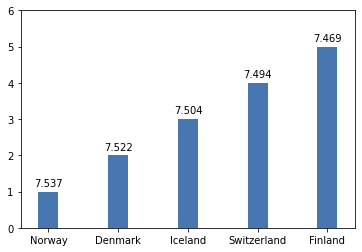

In [ ]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
plt.ylim(top=top5['Happiness.Rank'].count() + 1)
ax.vlines(x=top5.index, ymin=0, ymax=top5['Happiness.Rank'], color='#4876B0', linewidth=20)

for i, cty in enumerate(top5['Happiness.Rank']):
  score = top5['Happiness.Score'][i]
  score = round(score, 3)
  ax.annotate(score, xy=(i, cty + 0.1), horizontalalignment='center', verticalalignment='bottom')

plt.xticks(top5.index, top5['Country'], horizontalalignment='center')
ax.margins(0.1)  # Что-бы не липло к краям
plt.show()

#Пункт 2
График зависимости уровня свободы от уровня счастья, указав на графике отклонения при помощи box whisker chart


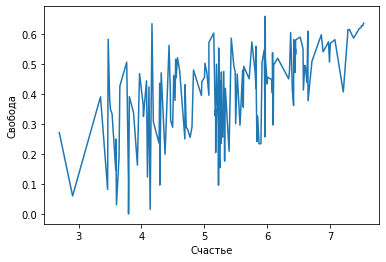

In [ ]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
ax.plot(report['Happiness.Score'], report['Freedom'])
ax.set_xlabel('Счастье')
ax.set_ylabel('Свобода')

plt.show()

#Пункт 3
Облако точек зависимости уровня "**счастья**" от уровня ВВП страны;



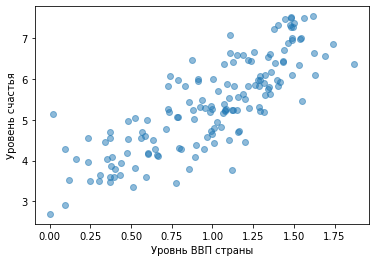

In [ ]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
ax.scatter(report['Economy..GDP.per.Capita.'], report['Happiness.Score'], alpha=0.5)
ax.set_xlabel('Уровнь ВВП страны')
ax.set_ylabel('Уровень счастья')

plt.show()

#Пункт 4
Распределение по столбцу Family для различных значений уровня "**счастья**";


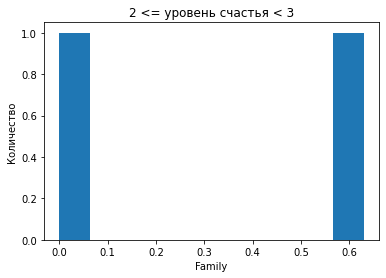

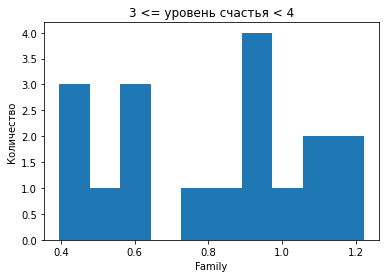

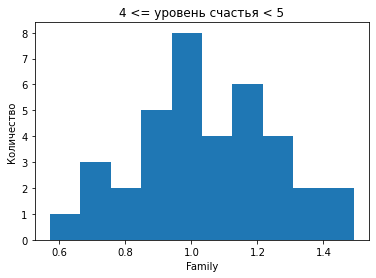

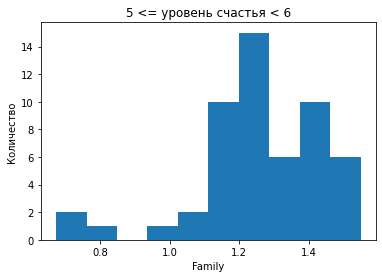

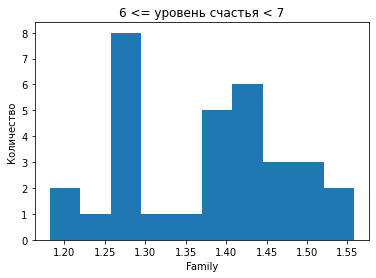

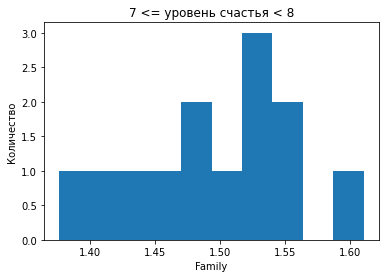

In [ ]:
import matplotlib.pyplot as plt

hap_min = int(report['Happiness.Score'].min())
hap_max = int(report['Happiness.Score'].max()) + 1

for i in range(hap_min, hap_max):
  _, ax = plt.subplots()
  ax.hist(report[(i <= report['Happiness.Score']) & (report['Happiness.Score'] < i + 1)]['Family'])

  ax.set_title(f'{i} <= уровень счастья < {i + 1}')
  ax.set_xlabel('Family')
  ax.set_ylabel('Количество')

plt.show()

#Пункт 5
Добавить в набор данных столбец с указанием экономического мира страны ("**первый мир**", "**второй мир**" и "**третий мир**") и визуализировать топ-5 стран с наивысшим рейтингом "счастья" для каждого из миров.

> Для полученения списка стран с указанием экономического мира страны ("**первый мир**", "**второй мир**" и "**третий мир**"), был [написан](Parser.ipynb) скрипт для парсингда данных с ресурса.

In [ ]:
country_economic_rang = pd.read_csv('https://gist.githubusercontent.com/Danil42Russia/5429c0f319ec969b761fd62e0a14ccb1/raw/44b39a0387ab2901acb095543109c9d255bf357f/country_economic_rang.csv')
country_economic_rang = country_economic_rang.rename(columns={'Number': 'Economic.world'})

country_economic_rang

,Country,Economic.world
0,Luxembourg,1
1,Ireland,1
2,Switzerland,1
3,Norway,1
4,United States,1
...,...,...
186,Venezuela,3
187,Vietnam,3
188,Yemen,3
189,Zambia,3


In [ ]:
country_rang = pd.merge(report, country_economic_rang, how='inner', on=['Country'])

country_rang

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual,Economic.world
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,1
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,1
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,1
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,1
4,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Rwanda,151,3.471,3.543030,3.398970,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061,3
145,Syria,152,3.462,3.663669,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574,3
146,Tanzania,153,3.349,3.461430,3.236570,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130,3
147,Burundi,154,2.905,3.074690,2.735310,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024,3


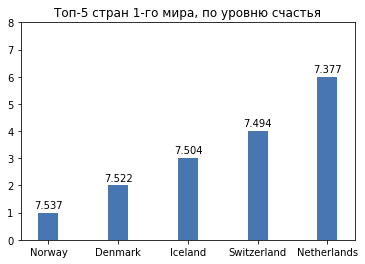

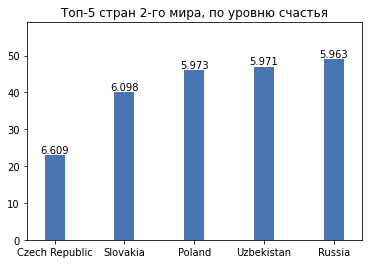

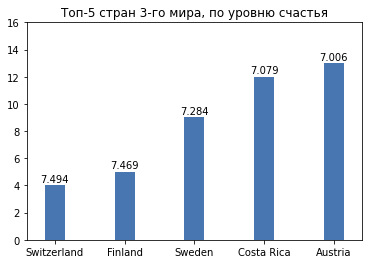

In [ ]:
import matplotlib.pyplot as plt
import math

country_rang_min = int(country_rang['Economic.world'].min())
country_rang_max = int(country_rang['Economic.world'].max()) + 1

for i in range(country_rang_min, country_rang_max):
  tmp = country_rang[country_rang['Economic.world'] == i].sort_values('Happiness.Rank').head(5).copy().reset_index()

  _, ax = plt.subplots()
  ax.set_title(f'Топ-5 стран {i}-го мира, по уровню счастья')

  plt.ylim(top=tmp['Happiness.Rank'].max() + math.ceil(tmp['Happiness.Rank'].max() / 5))
  ax.vlines(x=tmp.index, ymin=0, ymax=tmp['Happiness.Rank'], color='#4876B0', linewidth=20)

  for i, cty in enumerate(tmp['Happiness.Rank']):
      score = tmp['Happiness.Score'][i]
      score = round(score, 3)
      ax.annotate(score, xy=(i, cty + 0.1), horizontalalignment='center', verticalalignment='bottom')

  plt.xticks(tmp.index, tmp['Country'], horizontalalignment='center')
  ax.margins(0.1)

plt.show()